- Might be able to pick out the actual values from the discharge notes for the admitted then fill the rest with knn imputation.  Look for 'initial vitals', 'initial VS', "In the ED", "VS" and we can pull in order
- Can fill NA's with the values in the discharge details
- blood pressure can be found in this sequence 'sbp / dbp'
- admission exam (caps or no) header would be too far, that's for when they arrive in the hospital

**Potential Indicators**
- temperature
    - decimal point after two digits
    - letter T in front
- heart rate
    - HR
- resprate
    - letter R in front or RR
- o2sat
    - has a % attached to end
    - RA could be after
    - SpO2 could be before
- blood pressure
    - / in between
    - Could lead with SBP (space or no space)
    - BP in front

**Temp**
- *Normal range is 97 to 99.  Hypothermia is below 95.  Severe is below 82*
- *Hyperthermia is above 100.  Severe is above 104.  Have been recorded up to 110-115 but rare*
- Temperature outliers above 900 just need to move over a decimal place
- Handful are mid 100's, need to do something about that
- A lot of temperatures are below freezing.  Some of those are celsius.  But a lot are less than 10 which even converting to celsius would be too low.  I think above 28 C (extreme hypothermia and about 60 values are below that) and below 46 (about 350 values).  But a lot are between 46 and 80, not entirely sure what to do about that

`celsius eq is (C * 1.8) + 32`

**Heart rate**
- heartrate range on the upper end is 133 - 1228.  Only a handful in the range of 570 to 1228.  Rest are 256 and below which should be fine
- Only a handful below 20.  We can look at those specific patients and see what the deal is

**Respiratory rate**
- *normal rate is between 12 and 20.  above 20-25 can indicate tachypnea*
- some on the upper end could be fixed by moving 2 or 1 decimal place
- few hundred above 30/40 in the full range

**o2sat**
- *normal range is 95 - 100.  Dropping below 88 is dangerously low*
- Some of the really low ones are inaccurate.  But in the range of the 30's to 80's a lot are accurate and some aren't.  So best to validate with discharge detail notes
- there's one above 9000, that just needs to be moved two decimal places
- all the rest above 1000 can be normalized to 100
- anything starting with a 9 and 3 or 4 digits will be 90-something

**sbp**
- *normal range is between 90 and 120.  elevated is 120-140.  Hypertension is 140+*
- *Low can get 50-60.  below 50 is dangerous*
- Tentatively we can consider anything less than 40 in the data to be a mistake (about 200 values).  Maybe 24.  There's a jump between 19 and 24.  But only a handful are in the 24 - 40 range.
- sbp above
- below 260 might be accurate, need to validate that.  Above 260 is a mistake and pull first from discharge details

**dbp**
- *normal range is 60-80.  80 - 120+ is high to hypertensive.  50 starts to get low*
- Check anything less than 40
- check anything above 140
- need to do a check for rows where sbp is lower than dbp and for any float

In [ ]:
import pandas as pd
import numpy as np
import re
from utils.dataset_loader import mimic_loader
from utils.fix_triage_outliers import fix_triage_outliers

root = "ADS599-Capstone/raw_data"

In [2]:
df = mimic_loader(path=root, name='cohort_with_triage')

In [6]:
df.columns

Index(['subject_id', 'ed_stay_id', 'hadm_id', 'ed_intime', 'ed_outtime',
       'disposition', 'race', 'arrival_transport', 'first_careunit',
       'first_icu_intime', 'cohort_label', 'gender', 'anchor_age',
       'anchor_year', 'age_at_visit', 'dod', 'admittime', 'dischtime',
       'admission_type', 'discharge_location', 'insurance', 'language',
       'marital_status', 'ed_stay_id_2', 'stay_window_start',
       'stay_window_end', 'ed_boarding_time_hrs', 'temperature', 'heartrate',
       'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'acuity', 'chiefcomplaint'],
      dtype='str')

In [3]:
print(f"Number of patients: {df['subject_id'].nunique()}")
print(f"Unique number of ED stays: {df['ed_stay_id'].nunique()}")
print(f"Unique number of hospital admissions: {df['hadm_id'].nunique()}")

Number of patients: 196406
Unique number of ED stays: 397675
Unique number of hospital admissions: 192201


<Axes: >

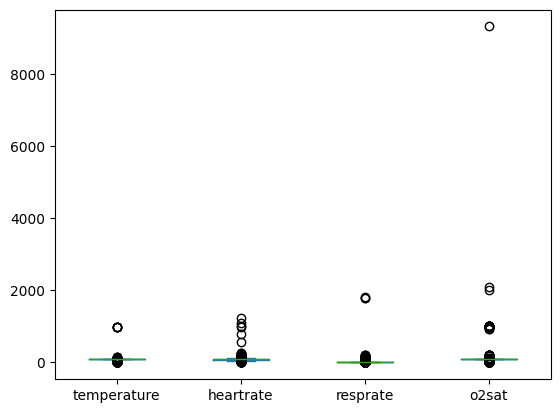

In [ ]:
df[['temperature', 'heartrate', 'resprate', 'o2sat']].plot(kind='box')

In [3]:
triage_check = df[['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']]

Q1 = triage_check.quantile(q=0.25, axis=0)
Q3 = triage_check.quantile(q=0.75, axis=0)
IQR = Q3 - Q1

upper_outliers = Q3 + (1.5 * IQR)
lower_outliers = Q1 - (1.5 * IQR)

In [4]:
triage_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']

print(f"{'Column':<15} {'Lower Thresh':>14} {'Upper Thresh':>14} {'# Below Lower':>14} {'# Above Upper':>14} {'Low Range':>20} {'High Range':>20}")
print("-" * 105)
for col in triage_cols:
    lo = lower_outliers[col]
    hi = upper_outliers[col]
    low_vals = triage_check[col][triage_check[col] < lo]
    high_vals = triage_check[col][triage_check[col] > hi]
    n_lo = len(low_vals)
    n_hi = len(high_vals)
    low_range = f"[{low_vals.min():.2f}, {low_vals.max():.2f}]" if n_lo > 0 else "none"
    high_range = f"[{high_vals.min():.2f}, {high_vals.max():.2f}]" if n_hi > 0 else "none"
    print(f"{col:<15} {lo:>14.2f} {hi:>14.2f} {n_lo:>14,} {n_hi:>14,} {low_range:>20} {high_range:>20}")

Column            Lower Thresh   Upper Thresh  # Below Lower  # Above Upper            Low Range           High Range
---------------------------------------------------------------------------------------------------------
temperature              95.85         100.25          2,275          9,554        [0.10, 95.80]     [100.30, 986.00]
heartrate                36.00         132.00            227          4,185        [1.00, 35.00]    [133.00, 1228.00]
resprate                 13.00          21.00          2,839         17,394        [0.00, 12.00]     [22.00, 1820.00]
o2sat                    92.50         104.50          4,926             46        [0.00, 92.00]    [107.00, 9322.00]
sbp                      78.00         190.00            912          6,506        [1.00, 77.00]  [191.00, 151103.00]
dbp                      39.50         115.50          1,756          3,824        [0.00, 39.00]  [116.00, 661672.00]


In [5]:
outlier_dfs = {}
for col in triage_cols:
    lo = lower_outliers[col]
    hi = upper_outliers[col]
    outlier_dfs[f'{col}_low'] = triage_check[triage_check[col] < lo].sort_values(col)
    outlier_dfs[f'{col}_high'] = triage_check[triage_check[col] > hi].sort_values(col, ascending=False)

In [47]:
outlier_dfs.keys()

dict_keys(['temperature_low', 'temperature_high', 'heartrate_low', 'heartrate_high', 'resprate_low', 'resprate_high', 'o2sat_low', 'o2sat_high', 'sbp_low', 'sbp_high', 'dbp_low', 'dbp_high'])

In [6]:
# removed duplicates then saved again to this file
notes_df = pd.read_csv("data/notes.csv")

In [7]:
full_df = df.merge(notes_df, on=['hadm_id', 'subject_id'], how='left')

In [92]:
print(f"Shape: {full_df.shape}")
print(f"Unique hadm_ids: {full_df['hadm_id'].nunique():,}")
print(f"\n--- NA counts per triage column ---")
for col in triage_cols:
    n_null = full_df[col].isna().sum()
    n_total = len(full_df)
    print(f"  {col:<15} null: {n_null:,} / {n_total:,}  ({n_null/n_total:.1%})")

print(f"\n--- Value ranges for non-null triage values ---")
print(full_df[triage_cols].describe().round(2))

print(f"\n--- Columns in full_df ---")
print(full_df.columns.tolist())

Shape: (397675, 39)
Unique hadm_ids: 192,201

--- NA counts per triage column ---
  temperature     null: 20,901 / 397,675  (5.3%)
  heartrate       null: 15,006 / 397,675  (3.8%)
  resprate        null: 18,076 / 397,675  (4.5%)
  o2sat           null: 18,285 / 397,675  (4.6%)
  sbp             null: 18,294 / 397,675  (4.6%)
  dbp             null: 16,842 / 397,675  (4.2%)

--- Value ranges for non-null triage values ---
       temperature  heartrate   resprate      o2sat        sbp        dbp
count    376774.00  382669.00  379599.00  379390.00  379381.00  380833.00
mean         98.08      84.97      17.56      98.39      98.40      81.20
std           1.20      17.70       2.38       2.11       2.08    1088.14
min           0.10      20.00       4.00      15.00      42.00       0.00
25%          97.52      72.00      16.00      97.00      97.00      68.00
50%          98.00      83.00      18.00      99.00      99.00      77.00
75%          98.60      96.00      18.00     100.00     1